In [147]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from vsa_ogm.mappers.sa.sa_vsa_mapper import make_good_unitary

In [148]:
d = 256

vectors = {
    "circle": make_good_unitary(d, "cpu"),
    "triangle": make_good_unitary(d, "cpu"),
    "square": make_good_unitary(d, "cpu"),
    "red": make_good_unitary(d, "cpu"),
    "green": make_good_unitary(d, "cpu"),
    "blue": make_good_unitary(d, "cpu"),
}

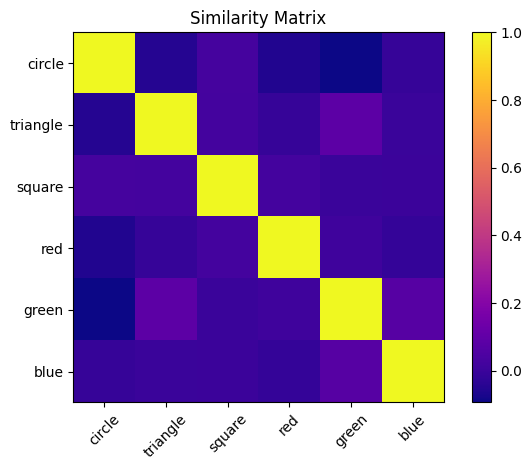

In [149]:
# compute the similarity between all vectors
sim_matrix = torch.zeros(6, 6)

for i in range(6):
    for j in range(6):
        sim_matrix[i, j] = torch.dot(vectors[list(vectors.keys())[i]], vectors[list(vectors.keys())[j]]).item()

# plot the similarity matrix
plt.imshow(sim_matrix, cmap="plasma", interpolation="nearest")
plt.colorbar()
plt.xticks(range(6), list(vectors.keys()), rotation=45)
plt.yticks(range(6), list(vectors.keys()))
plt.title("Similarity Matrix")
plt.tight_layout()
plt.savefig("similarity_matrix.png")

In [150]:
shape_vector = torch.zeros(d)
color_vector = torch.zeros(d)
for i, (key, vector) in enumerate(vectors.items()):
    if key in ["circle", "triangle", "square"]:
        shape_vector += vector
    else:
        color_vector += vector
shape_vector /= 3
color_vector /= 3

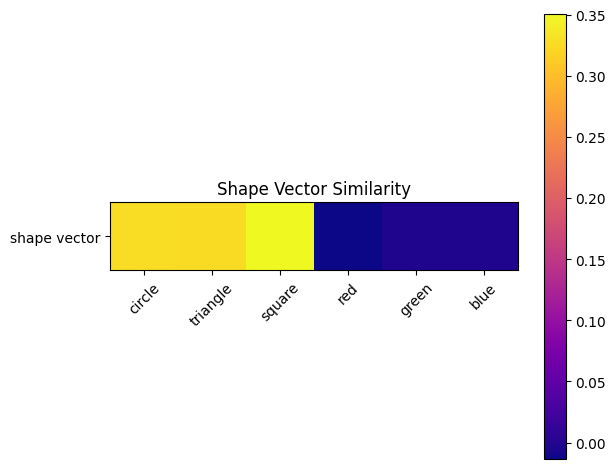

In [151]:
# compute the similarity between the shape vector and all vectors
shape_sim_matrix = torch.zeros(6)
for i in range(6):
    shape_sim_matrix[i] = torch.dot(shape_vector, vectors[list(vectors.keys())[i]]).item()
# plot the similarity matrix
plt.imshow(shape_sim_matrix.unsqueeze(0), cmap="plasma", interpolation="nearest")
plt.colorbar()
plt.xticks(range(6), list(vectors.keys()), rotation=45)
plt.yticks([0], ["shape vector"])
plt.title("Shape Vector Similarity")
plt.tight_layout()

Text(0.5, 1.0, 'Color Vector Similarity')

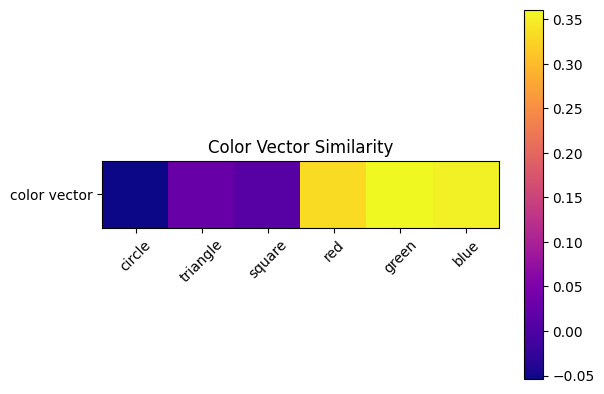

In [152]:
# compute the similarity between the color vector and all vectors
color_sim_matrix = torch.zeros(6)
for i in range(6):
    color_sim_matrix[i] = torch.dot(color_vector, vectors[list(vectors.keys())[i]]).item()
# plot the similarity matrix
plt.imshow(color_sim_matrix.unsqueeze(0), cmap="plasma", interpolation="nearest")
plt.colorbar()
plt.xticks(range(6), list(vectors.keys()), rotation=45)
plt.yticks([0], ["color vector"])
plt.title("Color Vector Similarity")

In [153]:
shape_color_bundle = torch.zeros(d)
shape_color_bundle += vectors["circle"]
shape_color_bundle += vectors["triangle"]
shape_color_bundle += vectors["red"]
shape_color_bundle += vectors["green"]

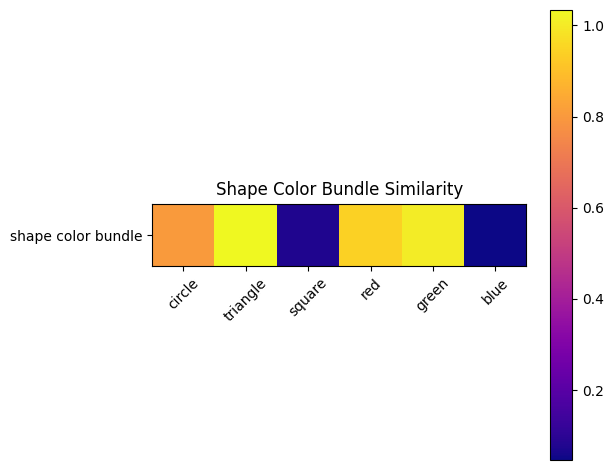

In [154]:
# plot the similarity with shape and color bundle
shape_color_sim_matrix = torch.zeros(6)
for i in range(6):
    shape_color_sim_matrix[i] = torch.dot(shape_color_bundle, vectors[list(vectors.keys())[i]]).item()
# plot the similarity matrix
plt.imshow(shape_color_sim_matrix.unsqueeze(0), cmap="plasma", interpolation="nearest")
plt.colorbar()
plt.xticks(range(6), list(vectors.keys()), rotation=45)
plt.yticks([0], ["shape color bundle"])
plt.title("Shape Color Bundle Similarity")
plt.tight_layout()
plt.savefig("shape_color_bundle.png")

In [171]:
def bind(vs, device: str) -> torch.tensor:
    """
    Bind all argued vectors into a single representation with circular
    convolution

    Arguments:
    ----------
    1) vs (torch.tensor or list[torch.tensor]): the given vectors that need
        to be bound together; can either be in the form of a tensor with
        shape = (num_vectors, num_vsa_dimensions), or a list of tensors of
        shape = (num_vsa_dimensions)
    2) device (str): where to load, store, and operator on tensors

    Returns:
    --------
    1) vs (torch.tensor): all input vector bound together with
        shape = (num_vsa_dimensions)
    """

    if isinstance(vs, list):
        ubvm_shape = (len(vs), vs[0].shape[-1])
        ubvm = torch.zeros(ubvm_shape, device=device)
        for i, value in enumerate(vs):
            ubvm[i, :] = value

        vs = ubvm

    vs = torch.fft.fft(vs, dim=1)
    vs = torch.prod(vs, dim=0)
    vs = torch.fft.ifft(vs).real
    return vs

In [174]:
shape_color_binded = torch.zeros(d)

print(vectors["circle"].shape)

shape_color_binded += bind([vectors["circle"], vectors["red"]], "cpu")
shape_color_binded += bind([vectors["triangle"], vectors["green"]], "cpu")

torch.Size([256])


tensor(-0.1151)
tensor(0.1672)


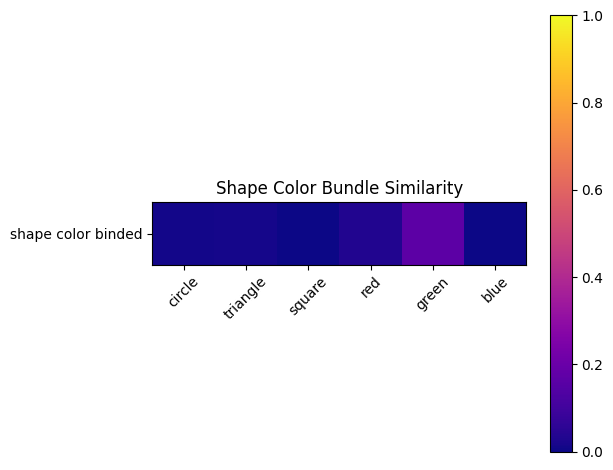

In [178]:
# plot the similarity with shape and color binded
shape_color_binded_sim_matrix = torch.zeros(6)
for i in range(6):
    shape_color_binded_sim_matrix[i] = torch.dot(
        shape_color_binded,
        vectors[list(vectors.keys())[i]]
    ).item()
# plot the similarity matrix

print(shape_color_binded_sim_matrix.min())
print(shape_color_binded_sim_matrix.max())

plt.imshow(shape_color_binded_sim_matrix.unsqueeze(0), cmap="plasma", interpolation="nearest", vmin=0, vmax=1)
plt.colorbar()
plt.xticks(range(6), list(vectors.keys()), rotation=45)
plt.yticks([0], ["shape color binded"])
plt.title("Shape Color Bundle Similarity")
plt.tight_layout()

In [160]:
def invert(ssp: torch.tensor) -> torch.tensor:
    """
    Return the pseudo inverse of the argued hypervector

    Arguments:
    ----------
    1) ssp (torch.tensor): a single hypervector based on Plate's
        "Holographic Reduced Representation"; shape = (num_vsa_dimensions)

    Returns:
    --------
    1) ssp (torch.tensor): the pseudo inverse of the argued ssp calculated
        by reversing the indices; shape = (num_vsa_dimensions)
    """
    return ssp[-torch.arange(ssp.shape[0])]

In [176]:
# invert the memory with the circle
circle_inverted = torch.zeros(d)

print(invert(vectors["square"]).shape)

circle_inverted = bind([invert(vectors["circle"]), shape_color_binded], "cpu")
print(circle_inverted.shape)

torch.Size([256])
torch.Size([256])


tensor(-0.1019)
tensor(1.0360)


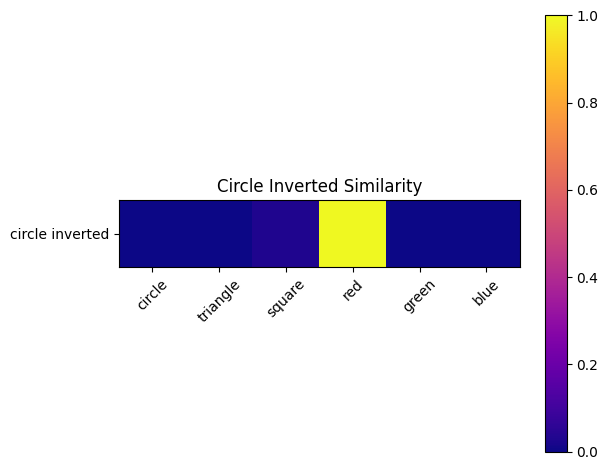

In [177]:
# plot the similarity with shape and color binded
circle_inverted_sim_matrix = torch.zeros(6)
for i in range(6):
    circle_inverted_sim_matrix[i] = torch.dot(
        circle_inverted,
        vectors[list(vectors.keys())[i]]
    ).item()

print(circle_inverted_sim_matrix.min())
print(circle_inverted_sim_matrix.max())

# plot the similarity matrix
plt.imshow(circle_inverted_sim_matrix.unsqueeze(0), cmap="plasma", interpolation="nearest", vmin=0, vmax=1)
plt.colorbar()
plt.xticks(range(6), list(vectors.keys()), rotation=45)
plt.yticks([0], ["circle inverted"])
plt.title("Circle Inverted Similarity")
plt.tight_layout()